In [1]:
import numpy as np
import pandas as pd

In [3]:
backcasting_scen2_type_split = pd.read_excel('type_split_backcasting_scenario2-kopi.xlsx')

In [6]:
split_2025 = type_split_matrix[years_excel == 2025][0]
split_2050 = np.array([0.0, 0.0, 1.0, 0.0])

# Ramp
ramp = np.clip((years_excel - 2025) / (2050 - 2025), 0, 1)

# Etagehus-andel interpoleres lineært fra 2025-verdi til 1.0
etagehus_2025 = split_2025[2]  # 0.554150557
etagehus_ramp = etagehus_2025 + ramp * (1.0 - etagehus_2025)  # (501,)

# De tre andre skaleres proporsjonalt slik at sum = 1
others_2025 = split_2025[[0, 1, 3]]  # Parcelhus, Rekkehus, Stuehus
others_sum_2025 = others_2025.sum()  # = 1 - etagehus_2025

# For hvert år: remaining = 1 - etagehus, fordel proporsjonalt
remaining = 1.0 - etagehus_ramp  # (501,)
others_ramp = remaining[:, np.newaxis] * (others_2025 / others_sum_2025)  # (501, 3)

# Sett sammen til (501, 4): Parcelhus, Rekkehus, Etagehus, Stuehus
type_split_future = np.concatenate([
    others_ramp[:, :2],          # Parcelhus, Rekkehus
    etagehus_ramp[:, np.newaxis],
    others_ramp[:, 2:]           # Stuehus
], axis=1)

# Overskriv fra 2025
idx_2025 = np.where(years_excel == 2025)[0][0]
type_split_matrix[idx_2025:, :] = type_split_future[idx_2025:, :]

# Skriv tilbake
backcasting_scen2_type_split[split_cols] = type_split_matrix

In [7]:
print(backcasting_scen2_type_split)  # Sjekk de første radene

     Year  Parcelhus  Rekkehus  Etagehus  Stuehus
0    1600        0.0       0.0       0.0      1.0
1    1601        0.0       0.0       0.0      1.0
2    1602        0.0       0.0       0.0      1.0
3    1603        0.0       0.0       0.0      1.0
4    1604        0.0       0.0       0.0      1.0
..    ...        ...       ...       ...      ...
496  2096        0.0       0.0       1.0      0.0
497  2097        0.0       0.0       1.0      0.0
498  2098        0.0       0.0       1.0      0.0
499  2099        0.0       0.0       1.0      0.0
500  2100        0.0       0.0       1.0      0.0

[501 rows x 5 columns]


In [8]:
print(backcasting_scen2_type_split[split_cols].sum(axis=1).unique())  # → [1.0]

[1.         1.         1.         1.         1.00027957 1.00034175
 1.00034327 1.00033053 1.00024049 1.00025005 1.0002416  1.00016648
 1.00019046 1.00021659 1.00039244 1.00109033 1.002115   1.00099951
 1.0005771  1.00054516 1.00042895 1.00082847 1.00031126 1.00014139
 1.00008498 1.000042   1.0000368  1.00004859 1.00005466 1.00004558
 1.00005515]


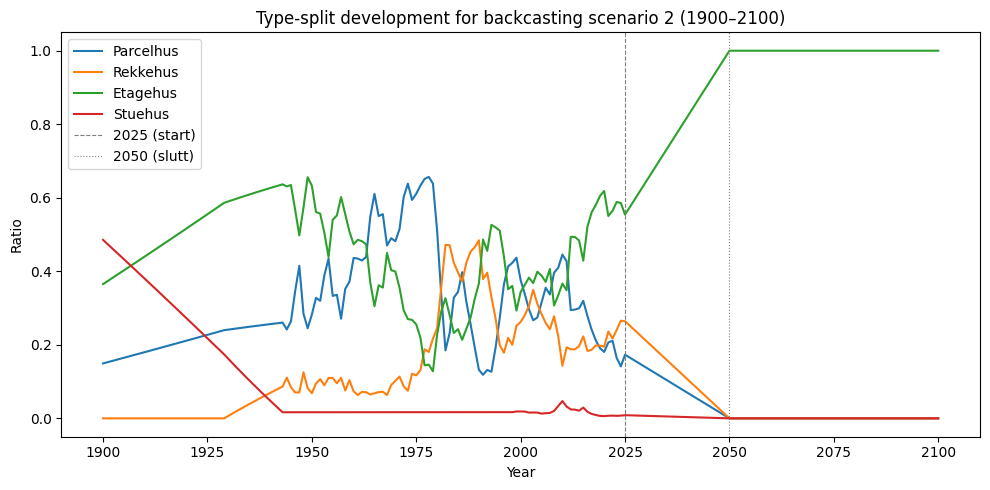

In [12]:
mask = years_excel >= 1900

fig, ax = plt.subplots(figsize=(10, 5))

for col in split_cols:
    ax.plot(years_excel[mask], backcasting_scen2_type_split.loc[mask, col], label=col)

ax.axvline(2025, color='gray', linestyle='--', linewidth=0.8, label='2025 (start)')
ax.axvline(2050, color='gray', linestyle=':',  linewidth=0.8, label='2050 (slutt)')

ax.set_xlabel('Year')
ax.set_ylabel('Ratio')
ax.set_title('Type-split development for backcasting scenario 2 (1900–2100)')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
backcasting_scen2_type_split.to_excel('type_split_backcasting_scenario2_output.xlsx', index=False)